# Gemma 3 vs Gemma 4: Road Sign Text Recognition
**CS153 Final Project Janav Shah & Florence Lin**

This notebook demonstrates our evaluation of two Google Gemma vision language models on their ability to read and interpret text embedded in road signs.

- **Gemma 3** (google/gemma-3-4b-it)
- **Gemma 4** (google/gemma-4-E4B-it)

Predictions were pre-computed and saved to outputs/predictions/. This notebook loads those results for visualization.

In [1]:
import os
import sys
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, os.path.dirname(os.getcwd()))
from config import DS1_LABELS, PROCESSED_DIR, PREDS_DIR, METRICS_DIR

TEXT_SIGNS = {
    'Speed limit (15km/h)', 'Speed limit (30km/h)', 'Speed limit (40km/h)',
    'Speed limit (50km/h)', 'Speed limit (5km/h)', 'Speed limit (60km/h)',
    'Speed limit (70km/h)', 'speed limit (80km/h)', 'Give Way', 'No entry',
    'No stopping', 'Horn', 'No horn', 'No Car', 'No Uturn',
    'Danger Ahead', 'Under Construction',
}

random.seed(42)
np.random.seed(42)
print('Setup complete.')

Setup complete.


## 1. Dataset Overview

In [2]:
labels_df = pd.read_csv(DS1_LABELS)
label_map = dict(zip(labels_df['ClassId'], labels_df['Name']))
meta_df   = pd.read_csv(os.path.join(PROCESSED_DIR, 'eval_metadata.csv'))

print(f'Total classes : {len(label_map)}')
print(f'Eval images   : {len(meta_df)}')
print(f'Text signs    : {meta_df["label_name"].isin(TEXT_SIGNS).sum()} ({meta_df["label_name"].isin(TEXT_SIGNS).mean()*100:.1f}%)')
print(f'Symbol signs  : {(~meta_df["label_name"].isin(TEXT_SIGNS)).sum()} ({(~meta_df["label_name"].isin(TEXT_SIGNS)).mean()*100:.1f}%)')

Total classes : 58
Eval images   : 171
Text signs    : 56 (32.7%)
Symbol signs  : 115 (67.3%)


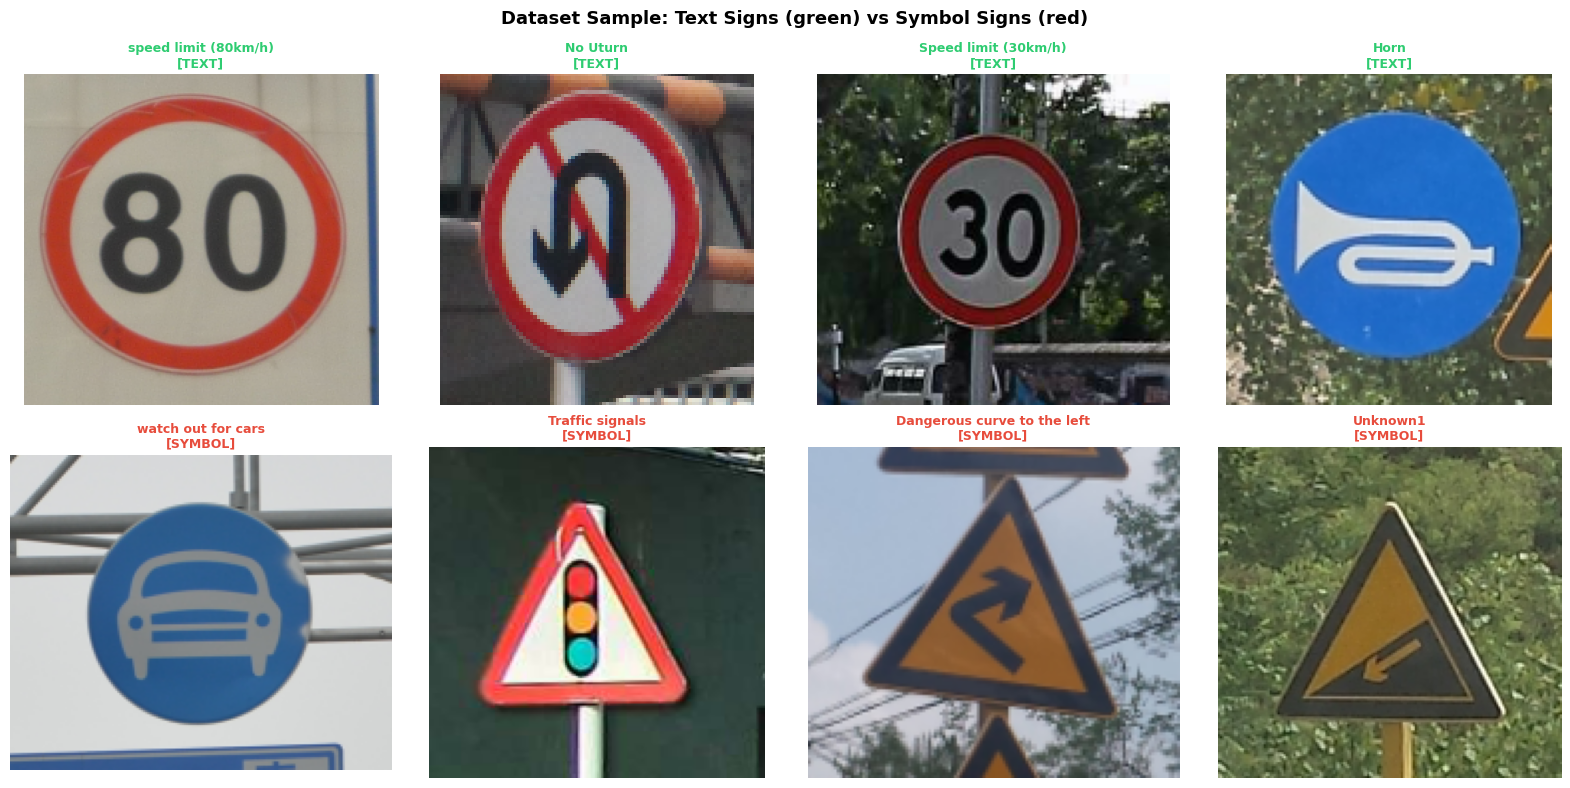

In [3]:
text_sample   = meta_df[meta_df['label_name'].isin(TEXT_SIGNS)].sample(4, random_state=42)
symbol_sample = meta_df[~meta_df['label_name'].isin(TEXT_SIGNS)].sample(4, random_state=42)
samples       = pd.concat([text_sample, symbol_sample])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    img = Image.open(row['image_path']).convert('RGB')
    ax.imshow(img)
    sign_type = 'TEXT' if row['label_name'] in TEXT_SIGNS else 'SYMBOL'
    color = '#2ecc71' if sign_type == 'TEXT' else '#e74c3c'
    ax.set_title(f"{row['label_name']}\n[{sign_type}]", fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

fig.suptitle('Dataset Sample: Text Signs (green) vs Symbol Signs (red)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Side-by-Side Model Predictions

In [4]:
g3_text = pd.read_csv(os.path.join(PREDS_DIR, 'gemma3_text_extraction.csv'))
g4_text = pd.read_csv(os.path.join(PREDS_DIR, 'gemma4_text_extraction.csv'))
g3_mean = pd.read_csv(os.path.join(PREDS_DIR, 'gemma3_meaning.csv'))
g4_mean = pd.read_csv(os.path.join(PREDS_DIR, 'gemma4_meaning.csv'))
print(f'Predictions loaded: {len(g3_text)} images each.')

Predictions loaded: 171 images each.


In [5]:
def norm(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def is_correct(pred, label):
    if 'km/h' in str(label).lower():
        nums = re.findall(r'\d+', str(label))
        return any(n in str(pred) for n in nums)
    return norm(str(label)) in norm(str(pred))

def show_predictions(df3, df4, title, n=8, only_text_signs=False):
    merged = df3.merge(df4, on=['image_path','class_id','label_name'], suffixes=('_g3','_g4'))
    if only_text_signs:
        merged = merged[merged['label_name'].isin(TEXT_SIGNS)]
    sample = merged.sample(min(n, len(merged)), random_state=42)

    fig, axes = plt.subplots(n, 3, figsize=(14, n * 2.8))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    for i, (_, row) in enumerate(sample.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')
        axes[i,0].imshow(img)
        axes[i,0].set_title(f"GT: {row['label_name']}", fontsize=8, fontweight='bold')
        axes[i,0].axis('off')

        for j, (pred_col, name) in enumerate([('pred_1_g3','Gemma 3'), ('pred_1_g4','Gemma 4')]):
            correct = is_correct(row[pred_col], row['label_name'])
            axes[i,j+1].axis('off')
            axes[i,j+1].text(0.5, 0.5, str(row[pred_col]),
                ha='center', va='center', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='#2ecc71' if correct else '#e74c3c', alpha=0.3))
            axes[i,j+1].set_title(name, fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

print('Functions ready.')

Functions ready.


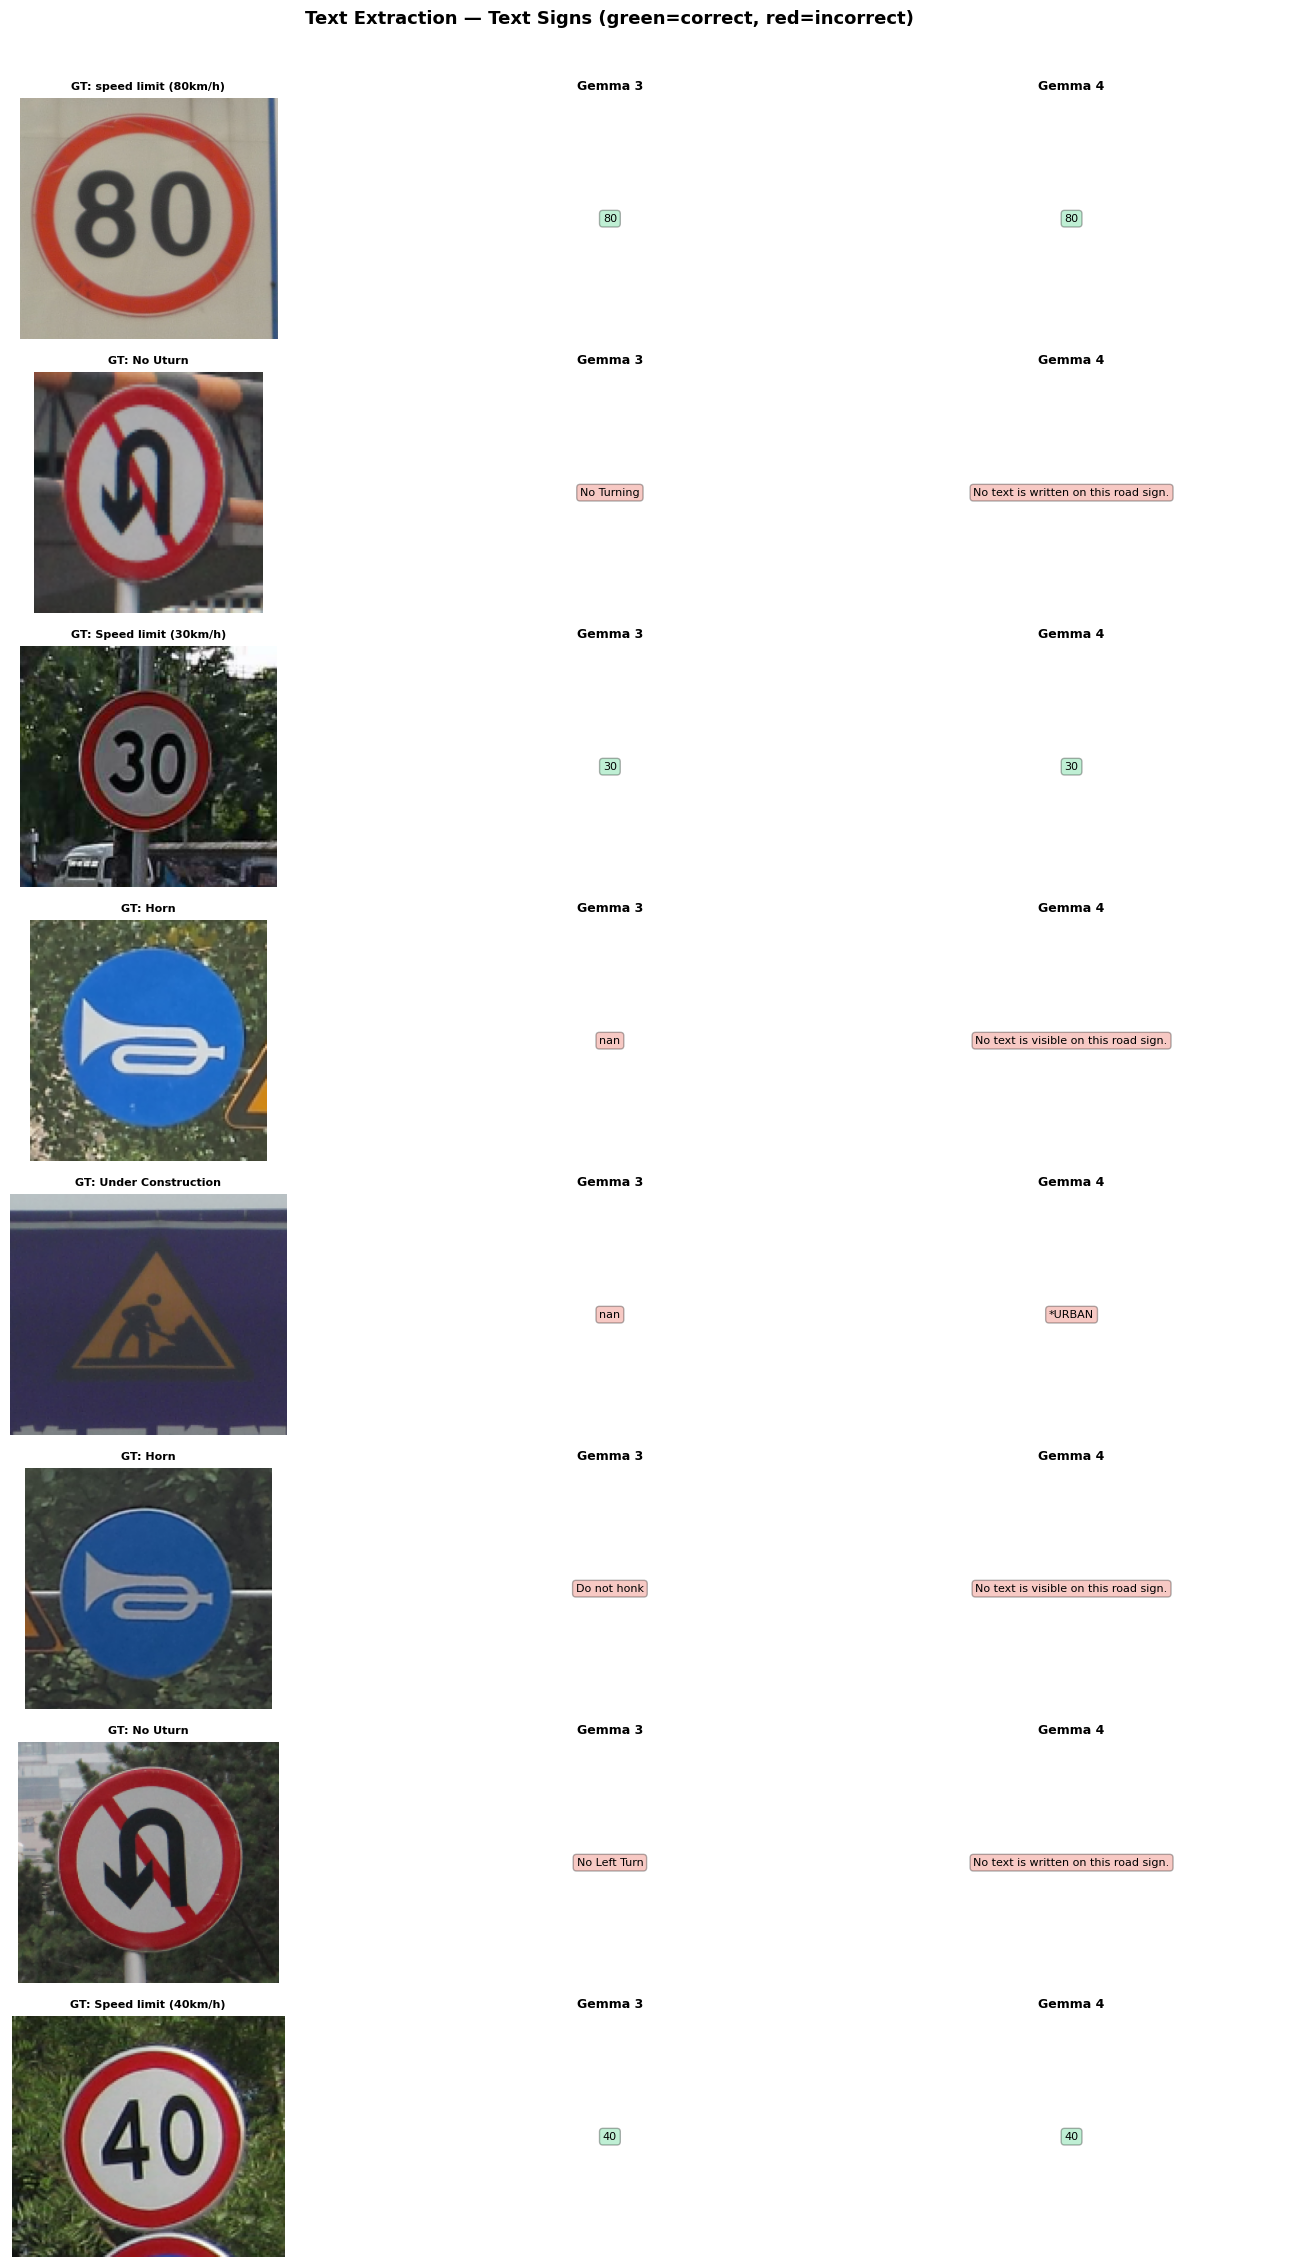

In [6]:
show_predictions(g3_text, g4_text,
    'Text Extraction — Text Signs (green=correct, red=incorrect)',
    n=8, only_text_signs=True)

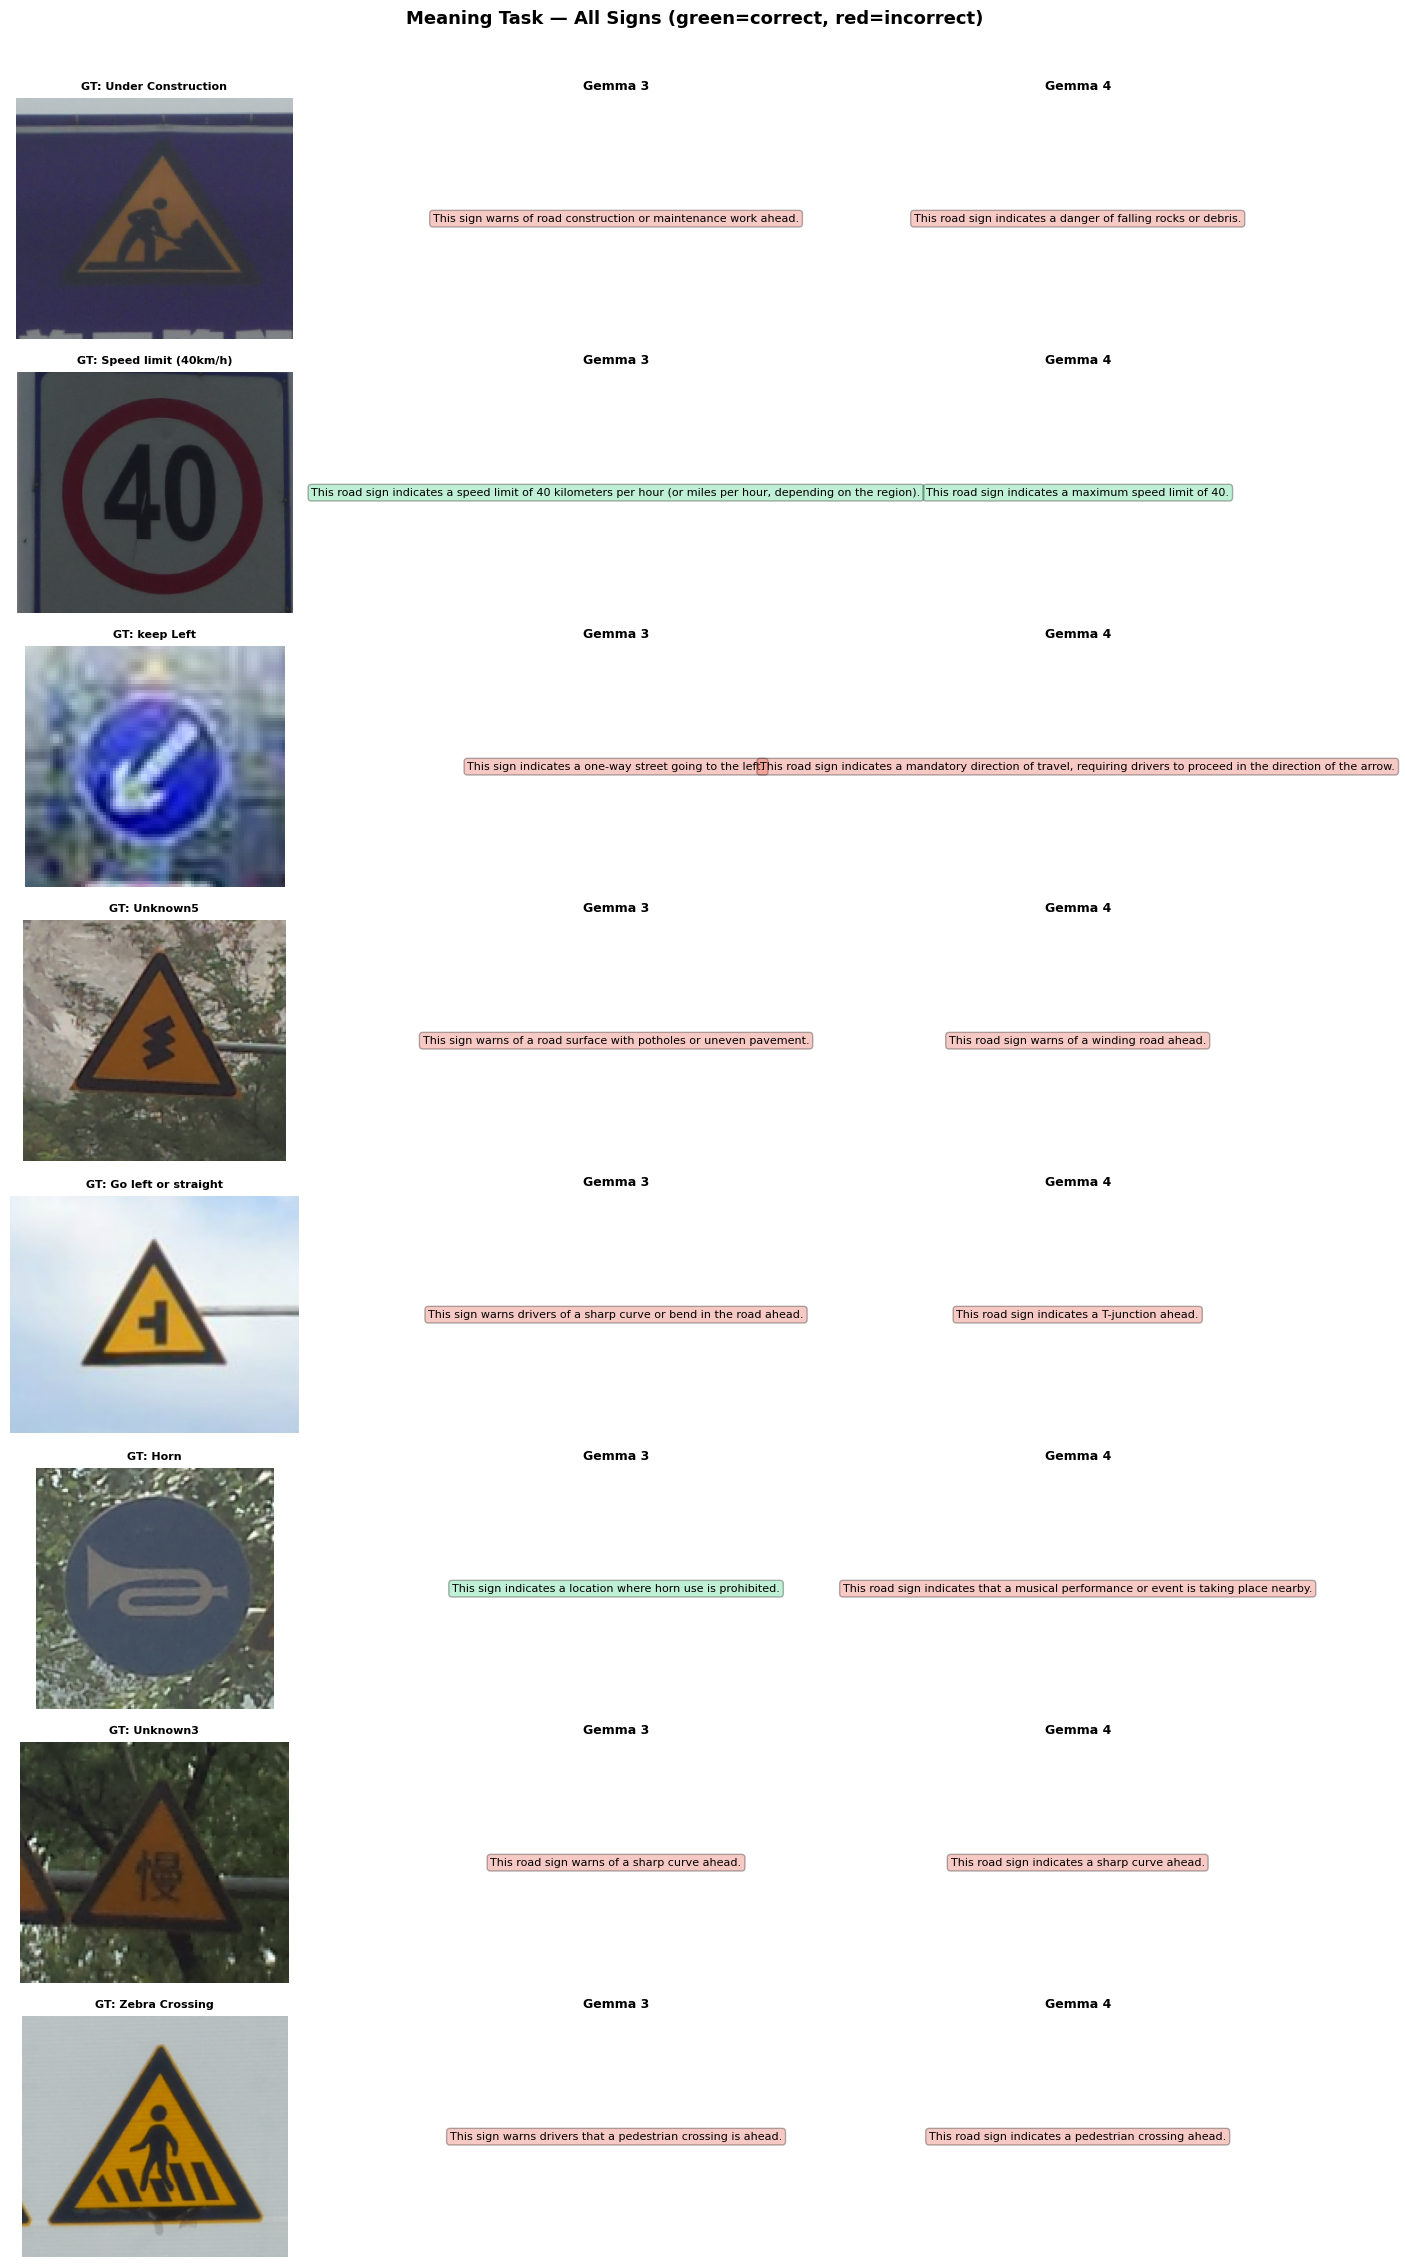

In [7]:
show_predictions(g3_mean, g4_mean,
    'Meaning Task — All Signs (green=correct, red=incorrect)',
    n=8, only_text_signs=False)

## 3. Evaluation Metrics

In [8]:
text_results = pd.read_csv(os.path.join(METRICS_DIR, 'text_extraction_results.csv'))
mean_results = pd.read_csv(os.path.join(METRICS_DIR, 'meaning_results.csv'))

print('=== TEXT EXTRACTION ===')
print(text_results.to_string(index=False))
print()
print('=== MEANING ===')
print(mean_results.to_string(index=False))

=== TEXT EXTRACTION ===
 model       subset  n_images  top1_accuracy  top3_accuracy  avg_bleu
gemma3          all       171         0.2105         0.2398    0.0950
gemma3   text_signs        56         0.6071         0.6964    0.1186
gemma3 symbol_signs       115         0.0174         0.0174    0.0835
gemma4          all       171         0.1754         0.1754    0.0121
gemma4   text_signs        56         0.5357         0.5357    0.0288
gemma4 symbol_signs       115         0.0000         0.0000    0.0040

=== MEANING ===
 model       subset  n_images  top1_accuracy  top3_accuracy  avg_bleu
gemma3          all       171         0.2339         0.2515    0.0937
gemma3   text_signs        56         0.6607         0.6607    0.1124
gemma3 symbol_signs       115         0.0261         0.0522    0.0846
gemma4          all       171         0.2164         0.2339    0.0916
gemma4   text_signs        56         0.5714         0.6250    0.1355
gemma4 symbol_signs       115         0.0435     

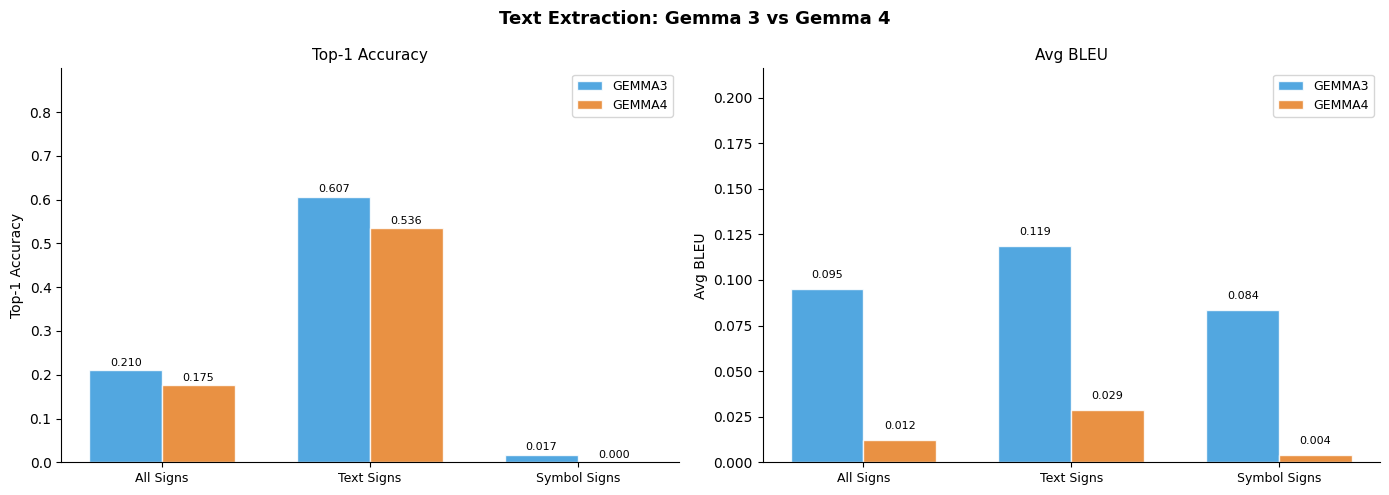

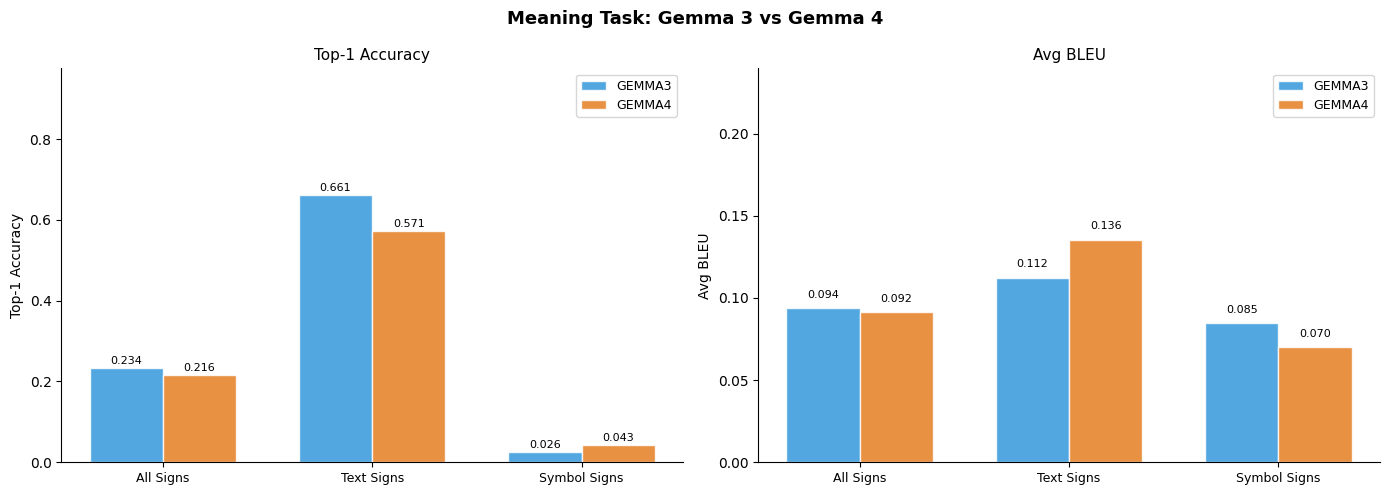

In [9]:
def plot_metrics(results_df, title):
    subsets = ['all', 'text_signs', 'symbol_signs']
    metrics = ['top1_accuracy', 'avg_bleu']
    metric_labels = ['Top-1 Accuracy', 'Avg BLEU']
    colors = {'gemma3': '#3498db', 'gemma4': '#e67e22'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for ax, metric, mlabel in zip(axes, metrics, metric_labels):
        x = np.arange(len(subsets))
        width = 0.35
        for i, model in enumerate(['gemma3', 'gemma4']):
            vals = [results_df[(results_df['model']==model) & (results_df['subset']==s)][metric].values[0]
                    for s in subsets]
            bars = ax.bar(x + i*width, vals, width, label=model.upper(),
                         color=colors[model], alpha=0.85, edgecolor='white')
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        ax.set_title(mlabel, fontsize=11)
        ax.set_xticks(x + width/2)
        ax.set_xticklabels(['All Signs', 'Text Signs', 'Symbol Signs'], fontsize=9)
        ax.set_ylim(0, results_df[metric].max() * 1.4 + 0.05)
        ax.legend(fontsize=9)
        ax.set_ylabel(mlabel)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_metrics(text_results, 'Text Extraction: Gemma 3 vs Gemma 4')
plot_metrics(mean_results,  'Meaning Task: Gemma 3 vs Gemma 4')

## 4. Our Findings

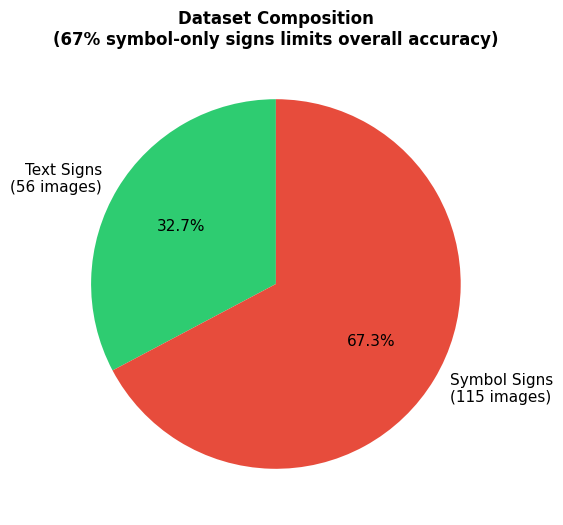

In [10]:
n_text   = meta_df['label_name'].isin(TEXT_SIGNS).sum()
n_symbol = len(meta_df) - n_text

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([n_text, n_symbol],
       labels=[f'Text Signs\n({n_text} images)', f'Symbol Signs\n({n_symbol} images)'],
       colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 11})
ax.set_title('Dataset Composition\n(67% symbol-only signs limits overall accuracy)',
             fontsize=12, fontweight='bold')
plt.show()

In [11]:
merged = g3_text.merge(g4_text, on=['image_path','class_id','label_name'], suffixes=('_g3','_g4'))
merged = merged[merged['label_name'].isin(TEXT_SIGNS)].copy()
merged['g3_correct'] = merged.apply(lambda r: is_correct(r['pred_1_g3'], r['label_name']), axis=1)
merged['g4_correct'] = merged.apply(lambda r: is_correct(r['pred_1_g4'], r['label_name']), axis=1)

disagree = merged[merged['g3_correct'] != merged['g4_correct']]
print(f'Cases where models disagree: {len(disagree)}')
print(disagree[['label_name','pred_1_g3','pred_1_g4','g3_correct','g4_correct']].to_string(index=False))

Cases where models disagree: 4
label_name pred_1_g3                             pred_1_g4  g3_correct  g4_correct
  No Uturn No U-Turn No text is written on this road sign.        True       False
  No entry  No entry (No text is visible on the road sign)        True       False
  No entry  No entry (No text is visible on the road sign)        True       False
  No entry  No entry No text is visible on this road sign.        True       False


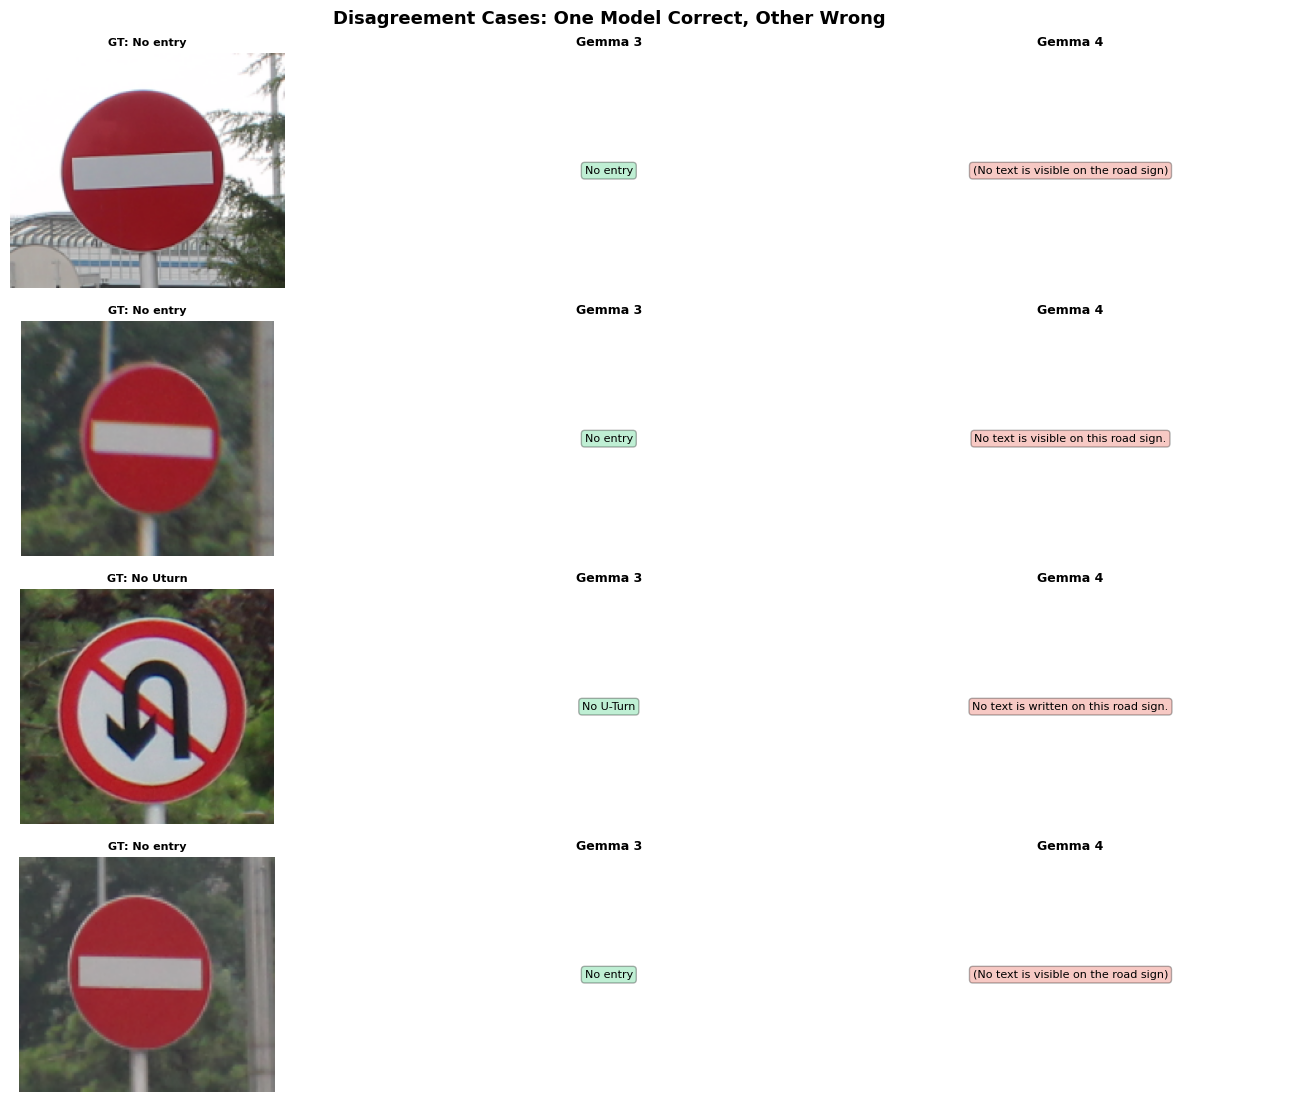

In [12]:
if len(disagree) > 0:
    n = min(6, len(disagree))
    sample = disagree.sample(n, random_state=42) if len(disagree) >= n else disagree
    fig, axes = plt.subplots(n, 3, figsize=(14, n * 2.8))
    if n == 1:
        axes = axes.reshape(1, -1)
    fig.suptitle('Disagreement Cases: One Model Correct, Other Wrong', fontsize=13, fontweight='bold')
    for i, (_, row) in enumerate(sample.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')
        axes[i,0].imshow(img)
        axes[i,0].set_title(f"GT: {row['label_name']}", fontsize=8, fontweight='bold')
        axes[i,0].axis('off')
        for j, (pred_col, name) in enumerate([('pred_1_g3','Gemma 3'),('pred_1_g4','Gemma 4')]):
            correct = row[f'g{j+3}_correct'.replace('g3_correct','g3_correct').replace('g4_correct','g4_correct')]
            correct = row['g3_correct'] if j==0 else row['g4_correct']
            axes[i,j+1].axis('off')
            axes[i,j+1].text(0.5, 0.5, str(row[pred_col]), ha='center', va='center',
                fontsize=8, bbox=dict(boxstyle='round', facecolor='#2ecc71' if correct else '#e74c3c', alpha=0.3))
            axes[i,j+1].set_title(name, fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Summary

| Finding | Detail |
|---|---|
| **Text sign accuracy** | Gemma 3: 60.7% Top-1, Gemma 4: 53.6% Top-1 (text extraction) |
| **Meaning task** | Gemma 4 higher BLEU on text signs (0.136 vs 0.112) — better semantic descriptions |
| **Symbol signs** | Both models ~0% — correctly refuse to invent text that isn't there |
| **Dataset limitation** | 67% of images are symbol-only signs, limiting overall accuracy |
| **Gemma 3 advantage** | More precise literal text extraction |
| **Gemma 4 advantage** | Better semantic understanding; more cautious on symbol signs |

## 6. Live Demo: US Road Signs Dataset (Real Driving Scenes)
This section loads full driving scene images, crops the annotated sign regions, and runs live inference with both models.

In [13]:
import torch
import json
from collections import defaultdict
from transformers import AutoProcessor, AutoModelForImageTextToText
from config import GEMMA3_MODEL_ID, GEMMA4_MODEL_ID, HF_CACHE_DIR, DS2_TRAIN_DIR, DS2_TRAIN_JSON

# Load annotations
with open(DS2_TRAIN_JSON) as f:
    coco = json.load(f)

cat_map = {c['id']: c['name'] for c in coco['categories']}
img_map = {img['id']: img for img in coco['images']}

# Group annotations by image, pick images that have exactly 1 sign for clean demo
from collections import defaultdict
anns_by_img = defaultdict(list)
for ann in coco['annotations']:
    anns_by_img[ann['image_id']].append(ann)

# Pick 6 images with 1 annotation each
demo_ids = [img_id for img_id, anns in anns_by_img.items() if len(anns) == 1][:6]
print(f'Selected {len(demo_ids)} demo images.')

Selected 6 demo images.


In [14]:
# Show the full scenes with bounding boxes drawn
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('US Road Signs Dataset — Full Driving Scenes with Bounding Boxes', fontsize=13, fontweight='bold')

for ax, img_id in zip(axes.flat, demo_ids):
    img_info = img_map[img_id]
    img_path = os.path.join(DS2_TRAIN_DIR, img_info['file_name'])
    img = Image.open(img_path).convert('RGB')
    
    ax.imshow(img)
    for ann in anns_by_img[img_id]:
        x, y, w, h = ann['bbox']
        rect = plt.Rectangle((x, y), w, h, linewidth=2, edgecolor='#e74c3c', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 4, cat_map[ann['category_id']], fontsize=8,
                color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#e74c3c', alpha=0.8))
    ax.axis('off')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
import json
import torch
import gc
from collections import defaultdict
from transformers import AutoProcessor, AutoModelForImageTextToText
from config import GEMMA3_MODEL_ID, GEMMA4_MODEL_ID, HF_CACHE_DIR, DS2_TRAIN_DIR, DS2_TRAIN_JSON

DEVICE = "cuda:1"

# Load annotations
with open(DS2_TRAIN_JSON) as f:
    coco = json.load(f)

cat_map = {c['id']: c['name'] for c in coco['categories']}
img_map = {img['id']: img for img in coco['images']}

anns_by_img = defaultdict(list)
for ann in coco['annotations']:
    anns_by_img[ann['image_id']].append(ann)

demo_ids = [img_id for img_id, anns in anns_by_img.items() if len(anns) == 1][:6]

def infer(processor, model, image, prompt):
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text",  "text": prompt},
    ]}]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True,
        tokenize=True, return_dict=True, return_tensors="pt",
    )
    inputs = {k: v.to(model.device) if hasattr(v, 'to') else v for k, v in inputs.items()}
    with torch.inference_mode():
        out = model.generate(**inputs, max_new_tokens=64, do_sample=False)
    prompt_len = inputs['input_ids'].shape[-1]
    return processor.decode(out[0][prompt_len:], skip_special_tokens=True).strip()

def get_crop(img_id):
    img_info = img_map[img_id]
    img = Image.open(os.path.join(DS2_TRAIN_DIR, img_info['file_name'])).convert('RGB')
    ann = anns_by_img[img_id][0]
    x, y, w, h = [int(v) for v in ann['bbox']]
    return img.crop((x, y, x+w, y+h)), cat_map[ann['category_id']]

PROMPT = "What text is written on this road sign? Reply with only the text you see, nothing else."
print('Setup done.')

In [ ]:
# Run Gemma 3 first, then free memory, then run Gemma 4
print('Loading Gemma 3...')
proc3 = AutoProcessor.from_pretrained(GEMMA3_MODEL_ID, cache_dir=HF_CACHE_DIR)
model3 = AutoModelForImageTextToText.from_pretrained(
    GEMMA3_MODEL_ID, device_map=DEVICE, torch_dtype=torch.bfloat16, cache_dir=HF_CACHE_DIR
).eval()

crops = [get_crop(img_id) for img_id in demo_ids]
g3_preds = [infer(proc3, model3, crop, PROMPT) for crop, _ in crops]
print('Gemma 3 done.')

# Free GPU memory
del model3
gc.collect()
torch.cuda.empty_cache()

print('Loading Gemma 4...')
proc4 = AutoProcessor.from_pretrained(GEMMA4_MODEL_ID, cache_dir=HF_CACHE_DIR)
model4 = AutoModelForImageTextToText.from_pretrained(
    GEMMA4_MODEL_ID, device_map=DEVICE, torch_dtype=torch.bfloat16, cache_dir=HF_CACHE_DIR
).eval()

g4_preds = [infer(proc4, model4, crop, PROMPT) for crop, _ in crops]
print('Gemma 4 done.')

del model4
gc.collect()
torch.cuda.empty_cache()

results = [
    {'crop': crop, 'category': cat, 'gemma3': g3, 'gemma4': g4}
    for (crop, cat), g3, g4 in zip(crops, g3_preds, g4_preds)
]
for r in results:
    print(f"  [{r['category']}] G3: {r['gemma3'][:50]} | G4: {r['gemma4'][:50]}")

In [ ]:
# Visualize crops with predictions
fig, axes = plt.subplots(len(results), 3, figsize=(14, len(results) * 3))
fig.suptitle('Live Inference on Cropped US Road Signs', fontsize=13, fontweight='bold')

for i, r in enumerate(results):
    axes[i,0].imshow(r['crop'])
    axes[i,0].set_title(f"Category: {r['category']}", fontsize=9, fontweight='bold')
    axes[i,0].axis('off')

    for j, (pred, name) in enumerate([(r['gemma3'], 'Gemma 3'), (r['gemma4'], 'Gemma 4')]):
        axes[i,j+1].axis('off')
        axes[i,j+1].text(0.5, 0.5, pred, ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='#3498db' if j==0 else '#e67e22', alpha=0.2))
        axes[i,j+1].set_title(name, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()